# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1) Adding a penalty to MSE makes it so that the the model strays away from using very large coefficients. This helps prevent overfitting because the model is forced to stay simpler instead of fitting all of the noise in the data.
2) Regularization helps explore the bias-variance tradeoff by controlling the complexity of the model. As the penalty increases, the variance decreases but on the other hand, bias increases. By adjusting the penalty, we can find a balance where the model generalizes well to new data.
3) LASSO tends to make some coefficients equal to zero, which then we are able to see feature selection. On the other hand, ridge regression shrinks coefficients but does not set them exactly to zero. As a result, LASSO regression gives us simpler models, while ridge regression keeps all features but reduces their impact.
4) We scale variables so that all features are on the same scale this is because if we do not scale them, the ones with larger magnitudes would have too much influence over the penalty term and unfairly bias the model.
5) The penalty parameter α is typically selected using cross-validation. We try different values of α and choose the one that minimizes the validation error.
6) No, we usually do not include the penalty term when evaluating cross-validated MSE. This is because we care about how well the model predicts new data, not the size of the coefficients.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [24]:
#Q2.1
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars_hw = pd.read_csv('data/cars_hw.csv')
cars_hw['Age'] = 2026 - cars_hw['Make_Year']
X = cars_hw[['Mileage_Run', 'Age']]
y = cars_hw['Price']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


In [25]:
#Q2.2
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
coeffs = pd.Series(linreg.coef_, index=feature_names)

coeffs

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64

Answer: The sign for the interaction between Mileage_Run and Age is negative.

In [26]:
#Q2.3
from sklearn.linear_model import LassoCV
import numpy as np

# Ignoring convergence warnings for LassoCV, there was just so many iterations that it was taking a while to converge, and I wanted to get the results faster.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

lasso_alpha = lasso.alpha_
lasso_alpha

np.float64(88.58667904100822)

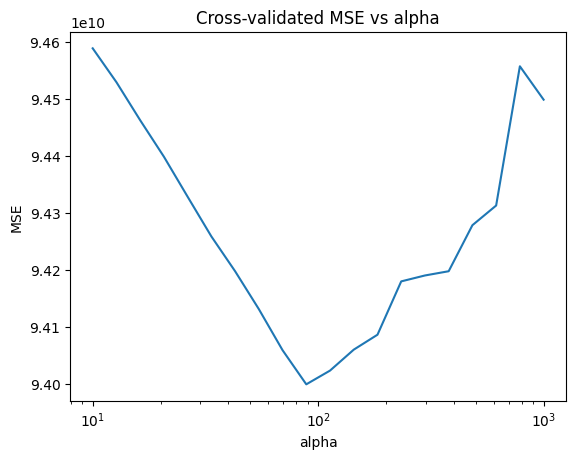

In [27]:
#Q2.4 
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('Cross-validated MSE vs alpha')
plt.show()

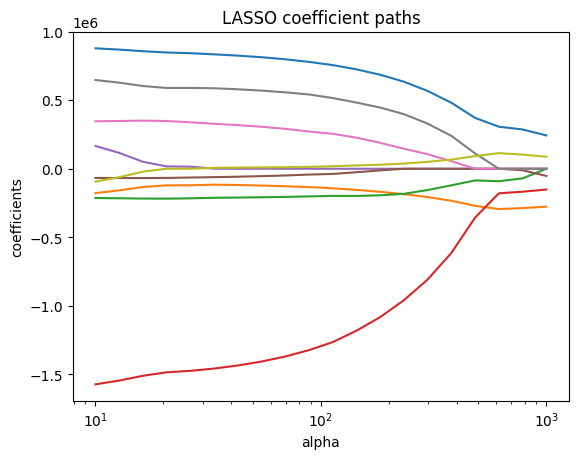

In [28]:
#Q2.5 
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('LASSO coefficient paths')
plt.show()

In [30]:
#Q2.6
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
zeroed = lasso_coefs[lasso_coefs == 0]

len(selected), len(zeroed), len(zeroed)/len(lasso_coefs)

(8, 1, 0.1111111111111111)

Answer: LASSO selects most of the features while shrinking a small number to zero. Out of 9 total features, 1 feature is set equal to zero, which is a proportion of approximately 0.11. This shows that LASSO performs some feature selection while still retaining most of the model terms.

In [31]:
#Q2.7

#checking to see which features were selected by LASSO and which were not, and comparing the signs of the coefficients to those from linear regression
comparison = pd.DataFrame({
    'Linear': linreg.coef_,
    'LASSO': lasso.coef_
}, index=feature_names)

comparison['Linear_sign'] = np.sign(comparison['Linear'])
comparison['LASSO_sign'] = np.sign(comparison['LASSO'])

comparison

,Linear,LASSO,Linear_sign,LASSO_sign
Mileage_Run,9.117748e+05,7.789506e+05,1.0,1.0
Age,-2.481722e+05,-1.337436e+05,-1.0,-1.0
Mileage_Run^2,-2.072926e+05,-2.006015e+05,-1.0,-1.0
Mileage_Run Age,-1.671212e+06,-1.323307e+06,-1.0,-1.0
Age^2,3.505507e+05,0.000000e+00,1.0,0.0
Mileage_Run^3,-6.514490e+04,-4.246012e+04,-1.0,-1.0
Mileage_Run^2 Age,3.388195e+05,2.705049e+05,1.0,1.0
Mileage_Run Age^2,7.167816e+05,5.428505e+05,1.0,1.0
Age^3,-2.100379e+05,1.334198e+04,-1.0,1.0


In [32]:
comparison[comparison['Linear_sign'] != comparison['LASSO_sign']]

,Linear,LASSO,Linear_sign,LASSO_sign
Age^2,350550.719877,0.000000,1.0,0.0
Age^3,-210037.887636,13341.983986,-1.0,1.0


Answer for Q2.7: Compared to linear regression, most coefficients in the LASSO model decrease in magnitude due to the regularization penalty. One coefficient (Age^2) is set exactly to 0, thus showing feature selection. Additionally, at least one coefficient (Age^3) changes sign from negative one in the linear model to positive one in the LASSO model. This shows how regularization can both shrink coefficients and alter their signs due to correlations between features.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [33]:
#Q3.1
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np


heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
y = heart['DEATH_EVENT']
X_cont = heart[['age', 'ejection_fraction', 'serum_creatinine']]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

# z-score normalize
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

X_dummy = heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_dummy = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_dummy_inter = poly_dummy.fit_transform(X_dummy)


X = np.concatenate([X_cont_scaled, X_dummy_inter], axis=1)
cont_names = poly_cont.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
dummy_names = poly_dummy.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
feature_names_q3 = np.concatenate([cont_names, dummy_names])

X.shape

(299, 29)

In [34]:
#Q3.2
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)

coeffs = pd.Series(linreg.coef_, index=feature_names_q3)
coeffs

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

Answer: Some sign patterns appear counterintuitive. For example, age has a positive coefficient, while higher-order terms such as age^2 have negative coefficients and age^3 becomes positive again. Similarly, ejection_fraction has a negative coefficient, but its higher-order terms can have different signs. At first, this seems contradictory because the effect of a variable appears to change direction. However, this is explained by the inclusion of higher-order polynomial terms and interactions. These allow the model to capture nonlinear relationships, meaning the effect of a variable can vary depending on its value. Instead of a single linear effect, the model represents more complex patterns, which resolves the apparent contradiction.

In [35]:
#Q3.3
import numpy as np
from sklearn.linear_model import LassoCV
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso.fit(X, y)

lasso.alpha_

np.float64(0.005736152510448681)

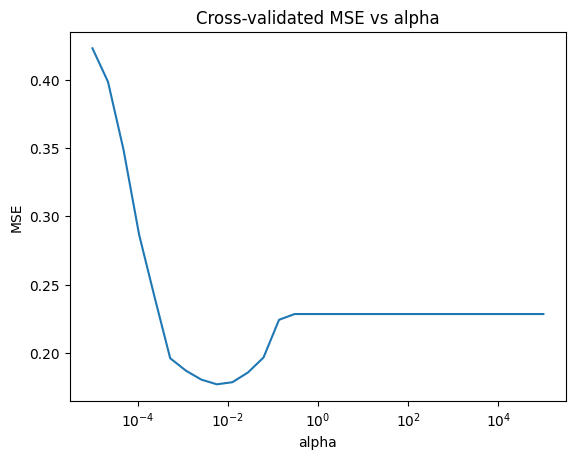

In [36]:
#Q3.4
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('Cross-validated MSE vs alpha')
plt.show()

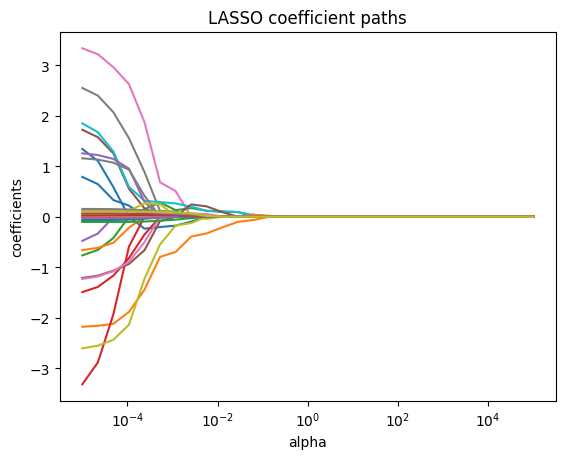

In [37]:
#Q3.5
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('LASSO coefficient paths')
plt.show()

In [38]:
#Q3.6
lasso_coefs = pd.Series(lasso.coef_, index=feature_names_q3)

selected = lasso_coefs[lasso_coefs != 0]
zeroed = lasso_coefs[lasso_coefs == 0]

len(selected), len(zeroed), len(zeroed)/len(lasso_coefs)

(12, 17, 0.5862068965517241)

In [39]:
comparison = pd.DataFrame({
    'Linear': linreg.coef_,
    'LASSO': lasso.coef_
}, index=feature_names_q3)

comparison['Linear_sign'] = np.sign(comparison['Linear'])
comparison['LASSO_sign'] = np.sign(comparison['LASSO'])

comparison[comparison['Linear_sign'] != comparison['LASSO_sign']]

,Linear,LASSO,Linear_sign,LASSO_sign
age,1.539156,-0.000000,1.0,0.0
serum_creatinine,-0.853588,0.116875,-1.0,1.0
age^2,-3.678654,0.000000,-1.0,0.0
age ejection_fraction,-0.600918,-0.000000,-1.0,0.0
age serum_creatinine,1.841563,0.000000,1.0,0.0
ejection_fraction^2,3.430976,0.000000,1.0,0.0
ejection_fraction serum_creatinine,2.673394,0.000000,1.0,0.0
serum_creatinine^2,-2.647041,-0.000000,-1.0,0.0
age^2 ejection_fraction,0.908026,0.000000,1.0,0.0
age^2 serum_creatinine,-0.697522,0.000000,-1.0,0.0


Answer: LASSO selects a subset of the features and sets many coefficients to zero. Out of 29 total features, 17 are set equal to zero, which is a proportion of approximately 0.59. This shows that LASSO performs substantial feature selection.

Compared to linear regression, most coefficients decrease in magnitude due to the regularization penalty, and many are shrunk exactly to zero. Some coefficients also change sign, indicating that regularization can alter the direction of relationships when features are highly correlated.

The sign patterns from the LASSO model appear more reasonable than those from the linear model. In the linear regression, some coefficients are difficult to interpret due to multicollinearity and the inclusion of many higher-order terms, which can lead to unstable estimates. LASSO reduces this complexity by shrinking or removing less important features, resulting in a simpler and more interpretable model.

From the perspective of the bias-variance trade-off, LASSO increases bias slightly by constraining the model but significantly reduces variance. This leads to better generalization and more stable coefficient estimates, which is why the LASSO results are more meaningful.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1) Answer: The objective function is the mean squared error plus a ridge penalty on the slope coefficient. The intercept b0 is not penalized.

2) Answer: After taking derivatives and setting them equal to zero, we get $b_0 = 0$ and
$$
b_1 = \frac{\frac{1}{n}\sum_{i=1}^{n} \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum_{i=1}^{n} \tilde{x}_i^2 + \alpha}
$$

3) Answer: As alpha increases, the slope coefficient gets smaller in magnitude. This is because the penalty becomes stronger, so the model shrinks the slope more toward zero. In other words, a larger alpha makes the fitted line flatter.

4) Answer: The issue with the LASSO penalty is that the absolute value of b1 is not differentiable at 0. This means we can’t just take a normal derivative and solve it like we did for ridge regression. Because of this, we have to think about cases, especially when b1 =0. LASSO has a “corner” at zero, which is what allows it to set coefficients exactly equal to zero. It is optimal to set b1 = 0​ when the relationship between x and y is weak. If the correlation between them is small compared to alpha, then the penalty is stronger than the benefit of keeping a nonzero slope, so the model just sets b1 to zero. So basically, LASSO can completely remove a variable when it’s not useful, unlike ridge which only shrinks it.